  Student_ID     Student_Name  Study_Hours  Attendance  Marks
0       S001      Mohit Gupta         10.8        50.6   97.0
1       S002    Vivaan Kapoor          7.6        62.2   70.0
2       S003      Aarush Shah         11.1        94.3   76.0
3       S004      Dhruv Kumar          2.0        60.2  100.0
4       S005  Siddharth Gupta          3.2        55.4    NaN
(100, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Student_ID    100 non-null    object 
 1   Student_Name  99 non-null     object 
 2   Study_Hours   98 non-null     float64
 3   Attendance    98 non-null     float64
 4   Marks         97 non-null     float64
dtypes: float64(3), object(2)
memory usage: 4.0+ KB
None
Student_ID      0
Student_Name    1
Study_Hours     2
Attendance      2
Marks           3
dtype: int64
       Study_Hours  Attendance       Marks
count    92.

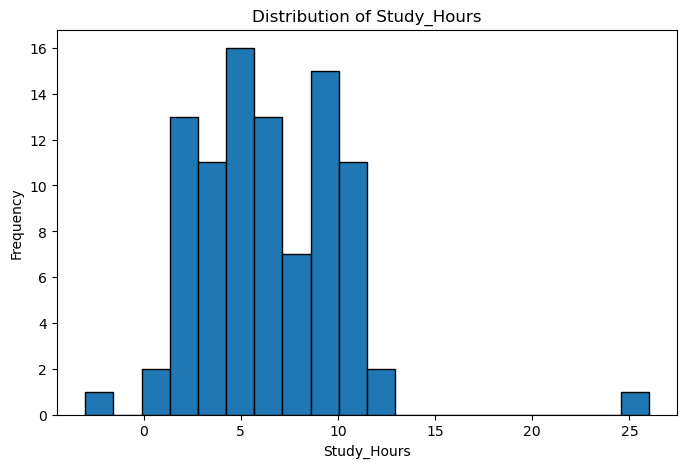

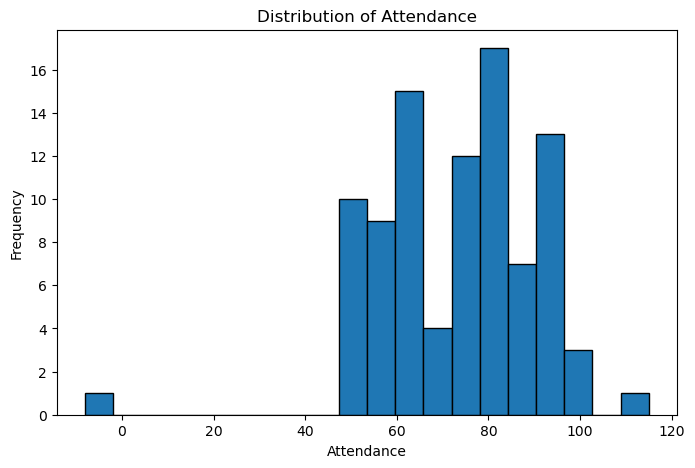

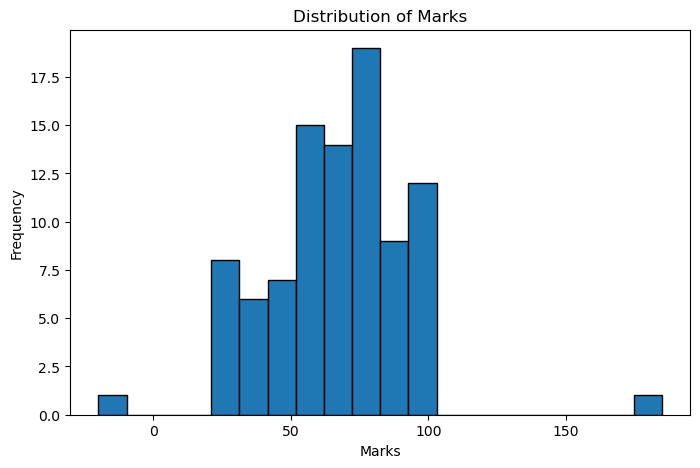

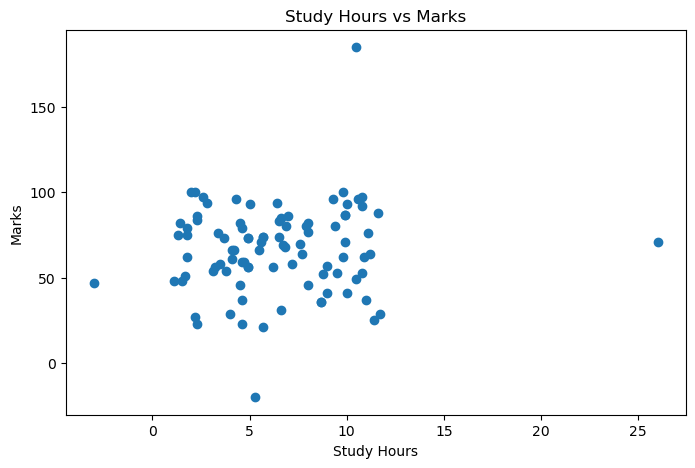

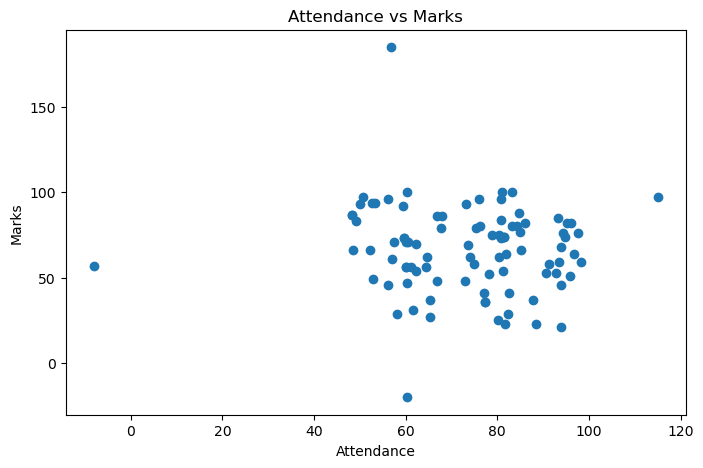

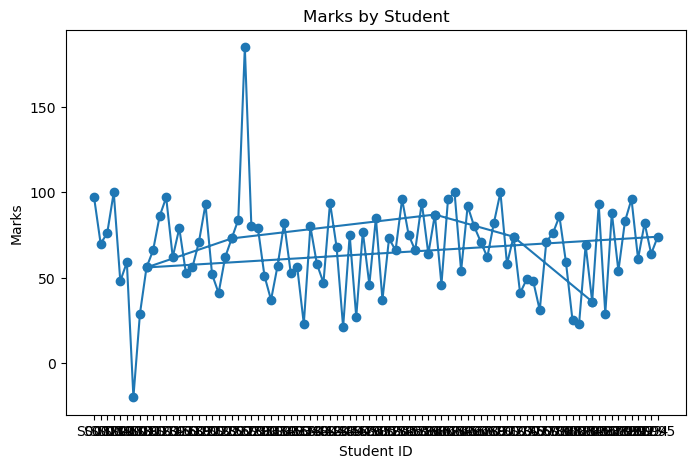

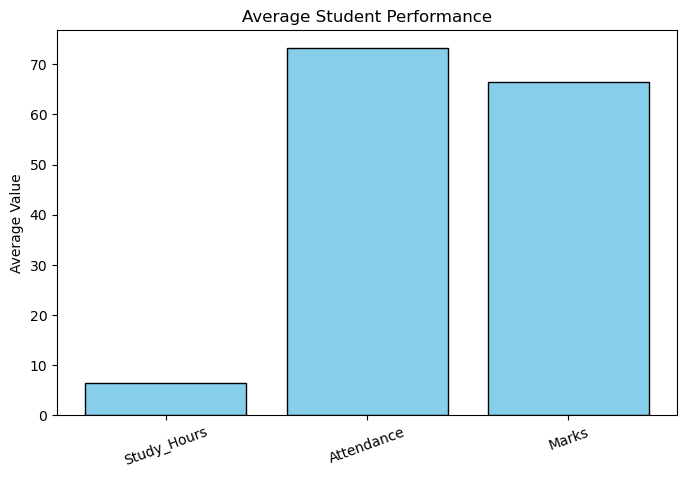

Correlation Matrix:
             Study_Hours  Attendance     Marks
Study_Hours     1.000000   -0.163051  0.090712
Attendance     -0.163051    1.000000 -0.072695
Marks           0.090712   -0.072695  1.000000


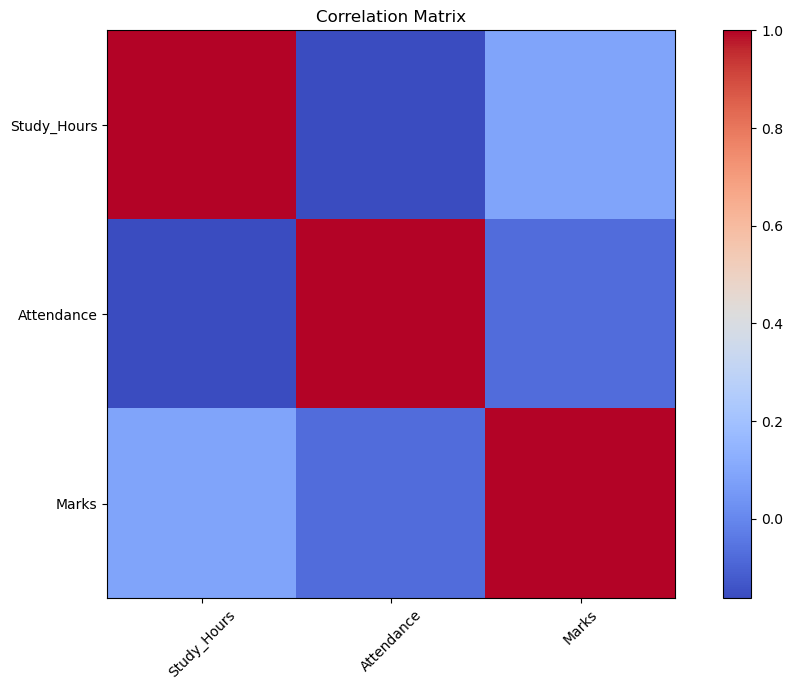

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("student_dataset_v2.csv")

print(df.head())
print(df.shape)
print(df.info())

print(df.isnull().sum())

df = df.dropna()

print(df.describe())

numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(df[column], bins=20, edgecolor="black")
    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["Study_Hours"], df["Marks"])
plt.title("Study Hours vs Marks")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["Attendance"], df["Marks"])
plt.title("Attendance vs Marks")
plt.xlabel("Attendance")
plt.ylabel("Marks")
plt.show()

if "Assignments" in df.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(df["Assignments"], df["Marks"])
    plt.title("Assignments vs Marks")
    plt.xlabel("Assignments")
    plt.ylabel("Marks")
    plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df["Student_ID"], df["Marks"], marker="o")
plt.title("Marks by Student")
plt.xlabel("Student ID")
plt.ylabel("Marks")
plt.show()

columns_for_average = ["Study_Hours", "Attendance", "Marks"]

if "Assignments" in df.columns:
    columns_for_average.insert(2, "Assignments")

plt.figure(figsize=(8, 5))

plt.bar(
    columns_for_average,
    [df[column].mean() for column in columns_for_average],
    color="skyblue",
    edgecolor="black"
)

plt.title("Average Student Performance")
plt.ylabel("Average Value")
plt.xticks(rotation=20)
plt.show()

correlation = df[numeric_columns].corr()

print("Correlation Matrix:")
print(correlation)

plt.figure(figsize=(10, 7))

plt.imshow(
    correlation,
    cmap="coolwarm",
    interpolation="none"
)

plt.colorbar()

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=45
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()